# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Gaming Vs Academic Dataset](https://www.kaggle.com/datasets/nalisha/gaming-vs-academic-performance)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('Gaming_Academic_Performance.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,1,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,Low,86.459555
1,2,19,Male,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,Medium,98.230000
2,3,23,Female,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,High,90.560000
3,4,20,Female,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,Low,32.670000
4,5,22,Female,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,Low,58.710000


## last Five row

In [4]:
df.tail()

,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
7995,7996,24,Male,6.33,5.09,4.83,63.74,FPS,4.11,9.96,231.33,11.14,Low,35.11
7996,7997,22,Female,5.77,6.09,6.23,84.37,FPS,3.42,11.19,254.13,10.66,Low,60.80
7997,7998,20,Male,2.87,8.51,8.62,67.30,FPS,2.36,6.40,305.00,6.42,Medium,90.28
7998,7999,22,Female,0.98,2.99,7.29,61.13,FPS,2.02,4.57,325.36,2.14,Medium,56.33
7999,8000,18,Female,1.73,8.75,7.65,78.68,RPG,4.03,6.33,302.25,4.05,Medium,100.00


## Shape of our dataset

In [5]:
df.shape

(8000, 14)

## List out all columns

In [6]:
df.columns

Index(['student_id', 'age', 'gender', 'gaming_hours', 'study_hours',
       'sleep_hours', 'attendance', 'gaming_genre', 'social_activity',
       'device_usage', 'reaction_time_ms', 'addiction_score', 'stress_level',
       'grades'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

student_id            int64
age                   int64
gender               object
gaming_hours        float64
study_hours         float64
sleep_hours         float64
attendance          float64
gaming_genre         object
social_activity     float64
device_usage        float64
reaction_time_ms    float64
addiction_score     float64
stress_level         object
grades              float64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        8000 non-null   int64  
 1   age               8000 non-null   int64  
 2   gender            8000 non-null   object 
 3   gaming_hours      8000 non-null   float64
 4   study_hours       8000 non-null   float64
 5   sleep_hours       8000 non-null   float64
 6   attendance        8000 non-null   float64
 7   gaming_genre      8000 non-null   object 
 8   social_activity   8000 non-null   float64
 9   device_usage      8000 non-null   float64
 10  reaction_time_ms  8000 non-null   float64
 11  addiction_score   8000 non-null   float64
 12  stress_level      8000 non-null   object 
 13  grades            8000 non-null   float64
dtypes: float64(9), int64(2), object(3)
memory usage: 875.1+ KB


## Check Null Value

In [9]:
df.isnull().sum()

student_id          0
age                 0
gender              0
gaming_hours        0
study_hours         0
sleep_hours         0
attendance          0
gaming_genre        0
social_activity     0
device_usage        0
reaction_time_ms    0
addiction_score     0
stress_level        0
grades              0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,student_id,age,gaming_hours,study_hours,sleep_hours,attendance,social_activity,device_usage,reaction_time_ms,addiction_score,grades
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,4000.50000,19.983625,4.085773,5.460581,6.493453,79.886525,2.507790,7.586315,271.105839,9.908492,66.180776
std,2309.54541,2.587072,2.308801,2.575787,1.442656,11.580419,1.441128,2.710035,29.440675,5.035837,22.422024
min,1.00000,16.000000,0.000000,1.000000,4.000000,60.000000,0.000000,1.100000,183.260000,-4.510000,0.000000
25%,2000.75000,18.000000,2.130000,3.240000,5.240000,69.780000,1.287500,5.560000,247.160000,5.920000,49.879843
50%,4000.50000,20.000000,4.130000,5.460000,6.505000,79.695000,2.500000,7.610000,270.475000,10.005000,67.070000
75%,6000.25000,22.000000,6.060000,7.660000,7.730000,90.100000,3.760000,9.600000,294.690000,13.860000,83.992223
max,8000.00000,24.000000,8.000000,10.000000,9.000000,100.000000,5.000000,13.950000,347.870000,23.160000,118.632936


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

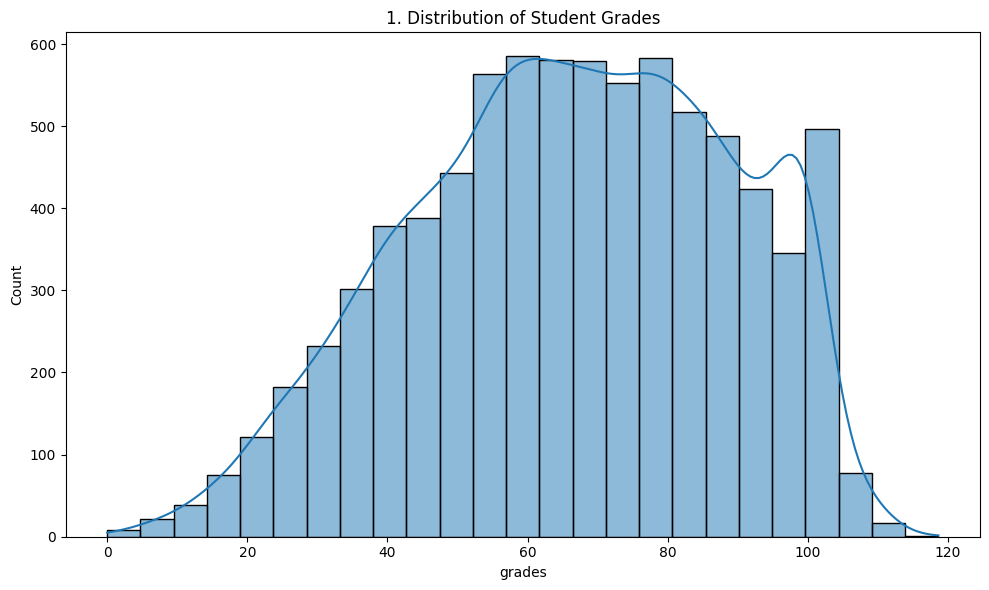

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['grades'], kde=True, bins=25)
plt.title(f'{plot_no}. Distribution of Student Grades')
show_fig()
plot_no += 1

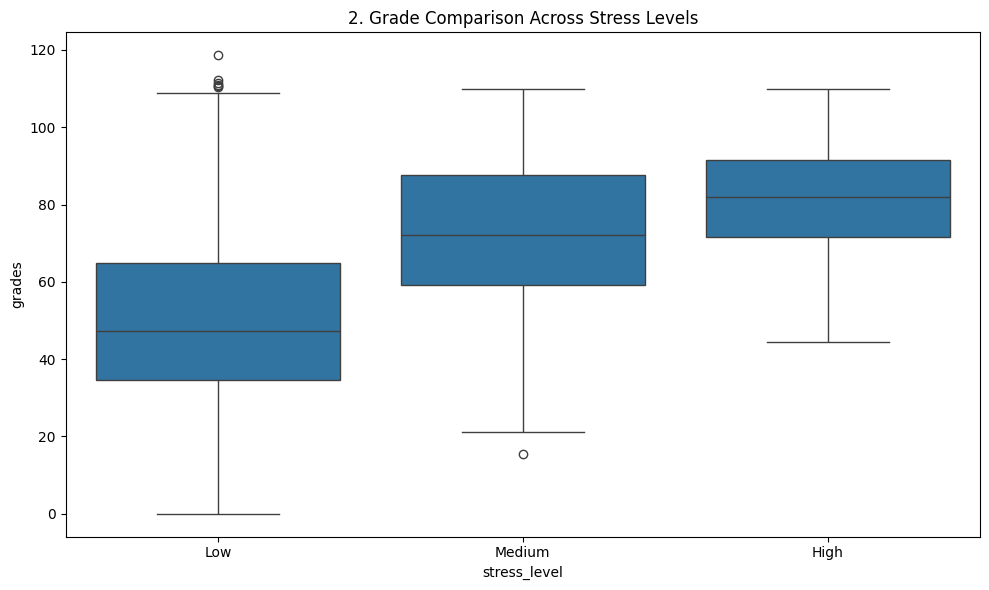

In [14]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='stress_level', y='grades', data=df, order=['Low', 'Medium', 'High'])
plt.title(f'{plot_no}. Grade Comparison Across Stress Levels')
show_fig()
plot_no += 1

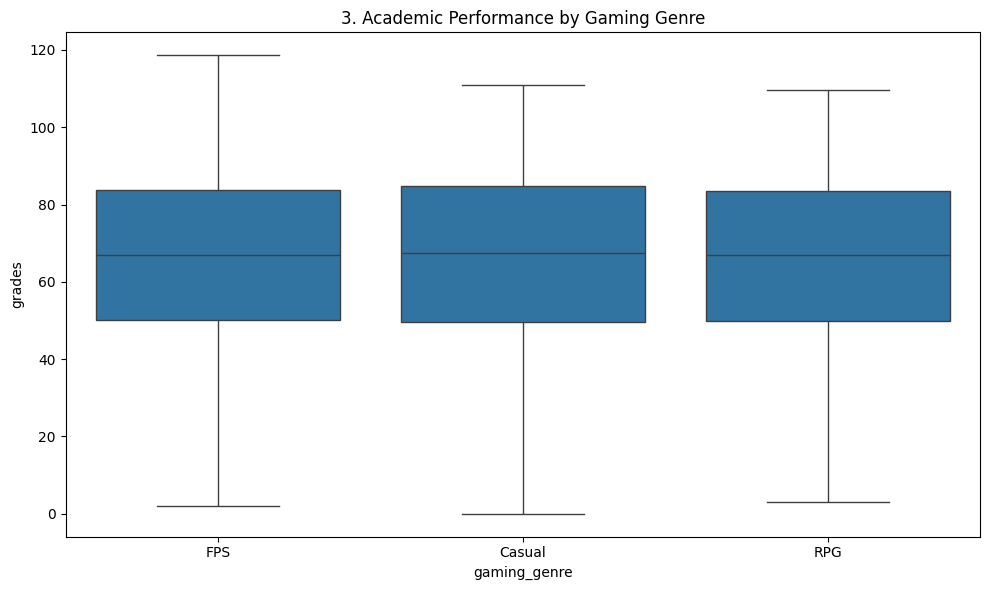

In [15]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='gaming_genre', y='grades', data=df)
plt.title(f'{plot_no}. Academic Performance by Gaming Genre')
show_fig()
plot_no += 1

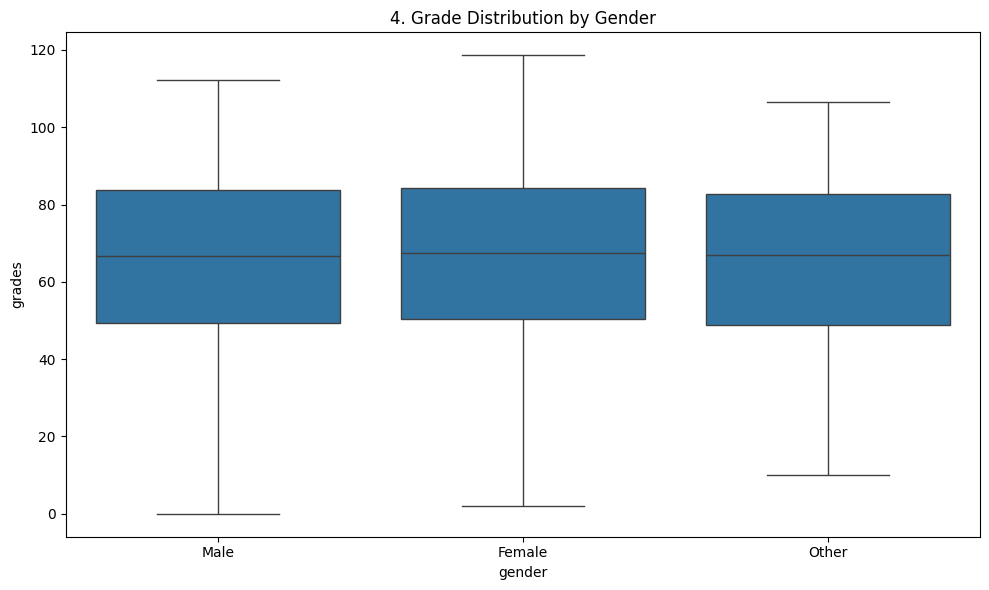

In [16]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='gender', y='grades', data=df)
plt.title(f'{plot_no}. Grade Distribution by Gender')
show_fig()
plot_no += 1

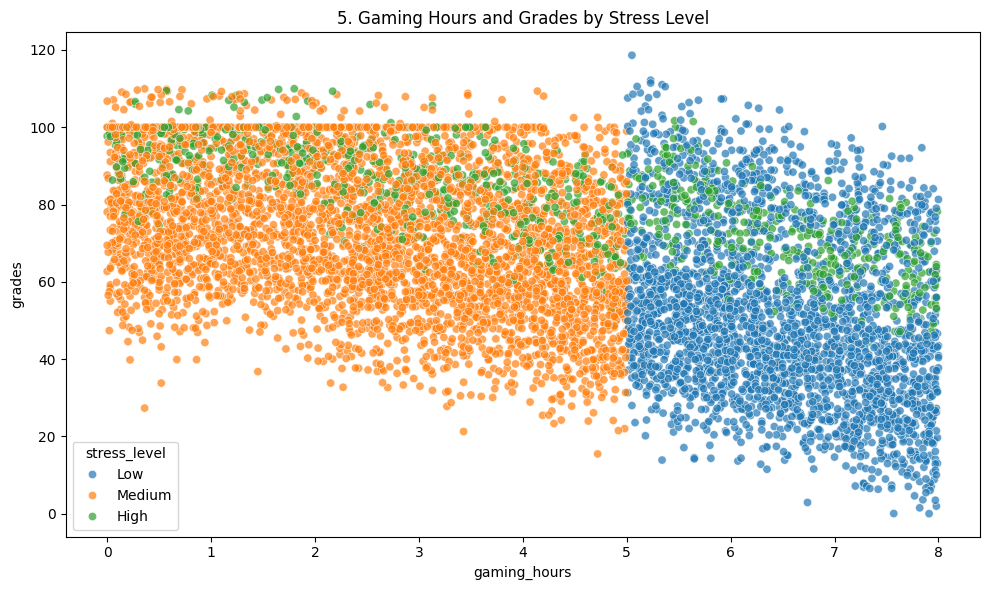

In [17]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='gaming_hours', y='grades', hue='stress_level', data=df, alpha=0.7)
plt.title(f'{plot_no}. Gaming Hours and Grades by Stress Level')
show_fig()
plot_no += 1

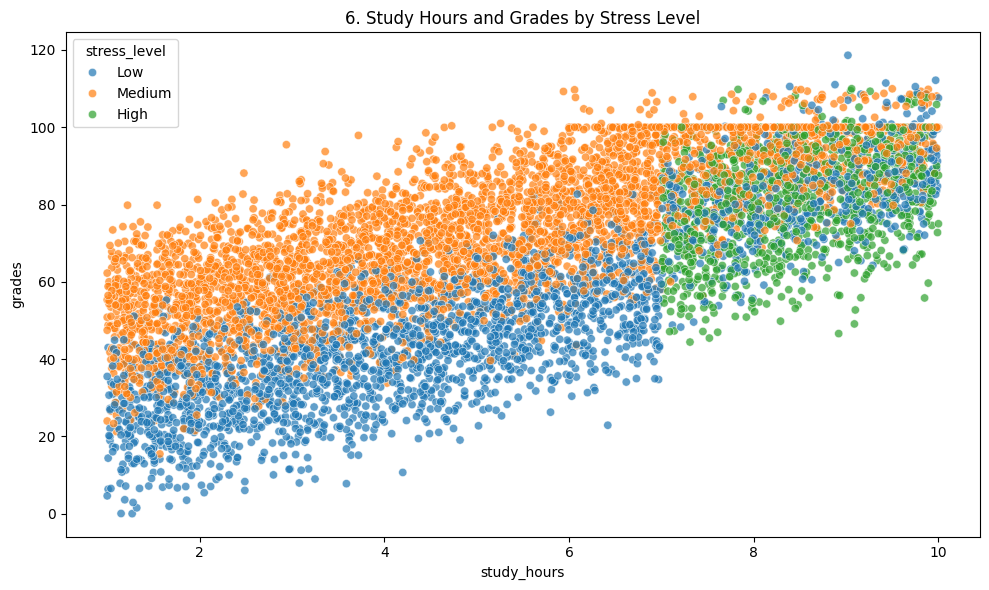

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='study_hours', y='grades', hue='stress_level', data=df, alpha=0.7)
plt.title(f'{plot_no}. Study Hours and Grades by Stress Level')
show_fig()
plot_no += 1

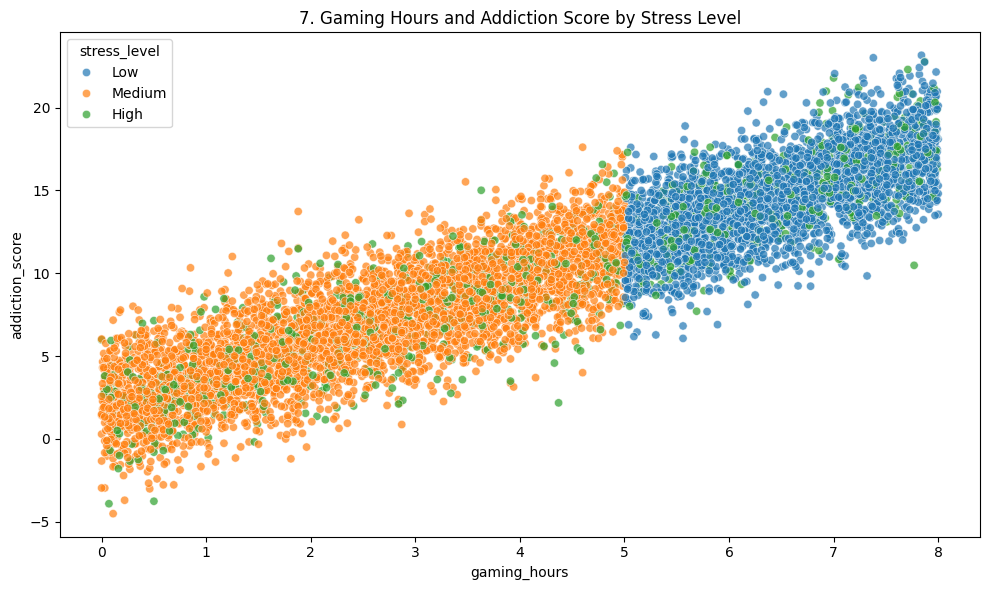

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='gaming_hours', y='addiction_score', hue='stress_level', data=df, alpha=0.7)
plt.title(f'{plot_no}. Gaming Hours and Addiction Score by Stress Level')
show_fig()
plot_no += 1

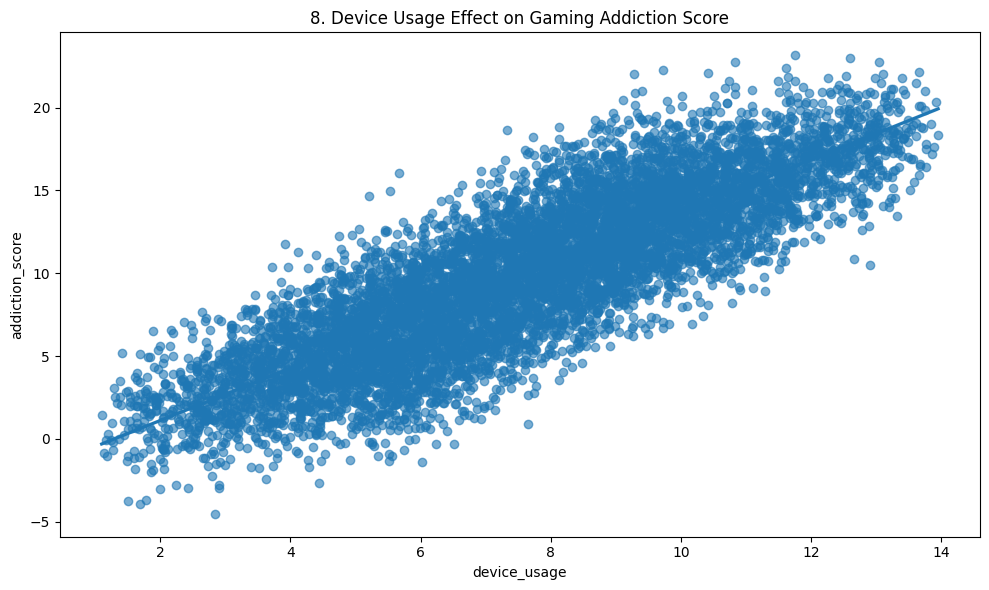

In [20]:
fig = plt.figure(figsize=(10,6))
sns.regplot(x='device_usage', y='addiction_score', data=df, scatter_kws={'alpha':0.6})
plt.title(f'{plot_no}. Device Usage Effect on Gaming Addiction Score')
show_fig()
plot_no += 1

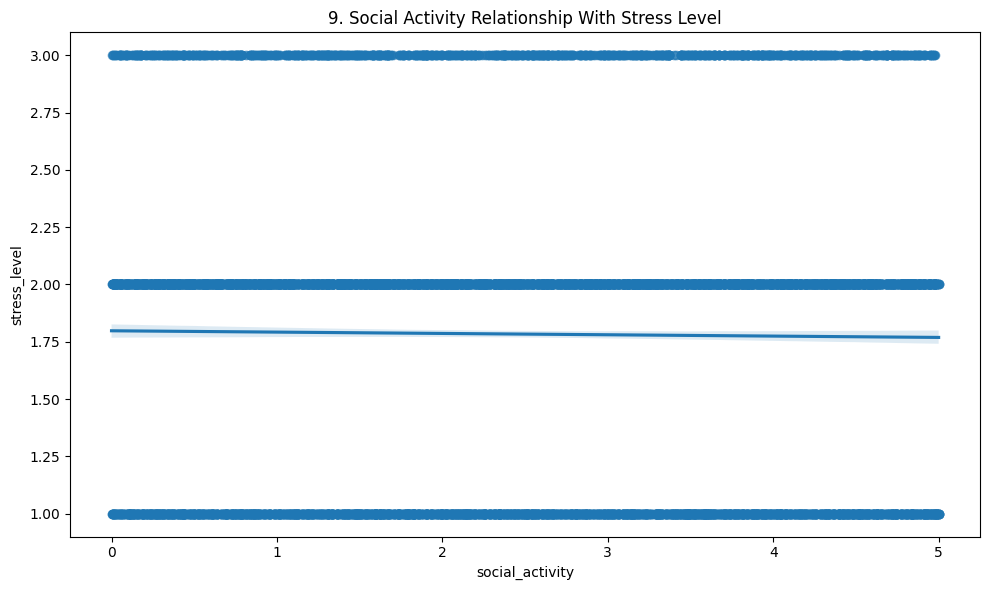

In [21]:
fig = plt.figure(figsize=(10,6))
sns.regplot(x='social_activity', y='stress_level', data=df.replace({'stress_level': {'Low': 1, 'Medium': 2, 'High': 3}}), scatter_kws={'alpha':0.6})
plt.title(f'{plot_no}. Social Activity Relationship With Stress Level')
show_fig()
plot_no += 1

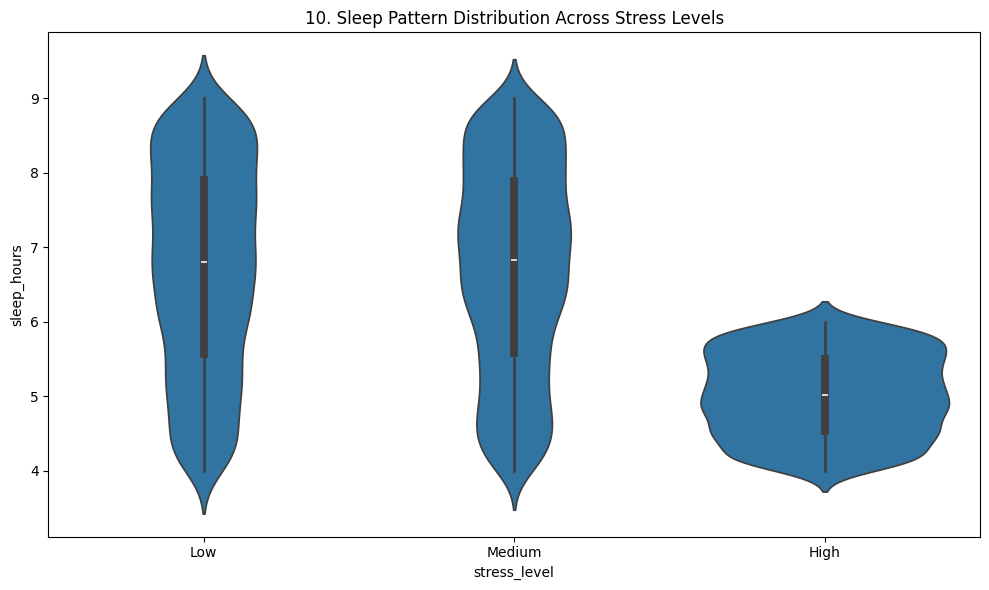

In [22]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(x='stress_level', y='sleep_hours', data=df, order=['Low', 'Medium', 'High'])
plt.title(f'{plot_no}. Sleep Pattern Distribution Across Stress Levels')
show_fig()
plot_no += 1

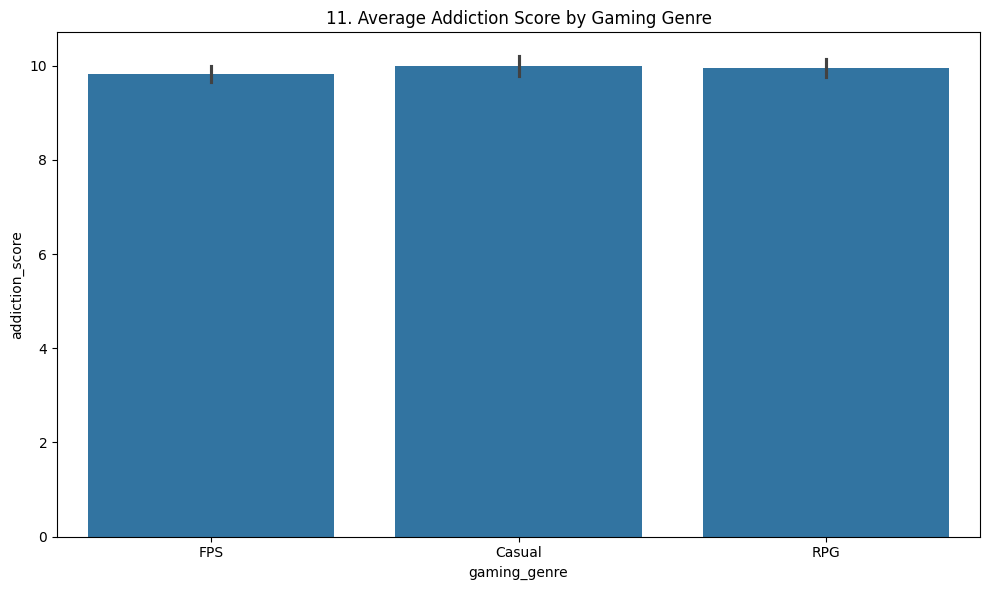

In [23]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='gaming_genre', y='addiction_score', data=df, estimator='mean')
plt.title(f'{plot_no}. Average Addiction Score by Gaming Genre')
show_fig()
plot_no += 1

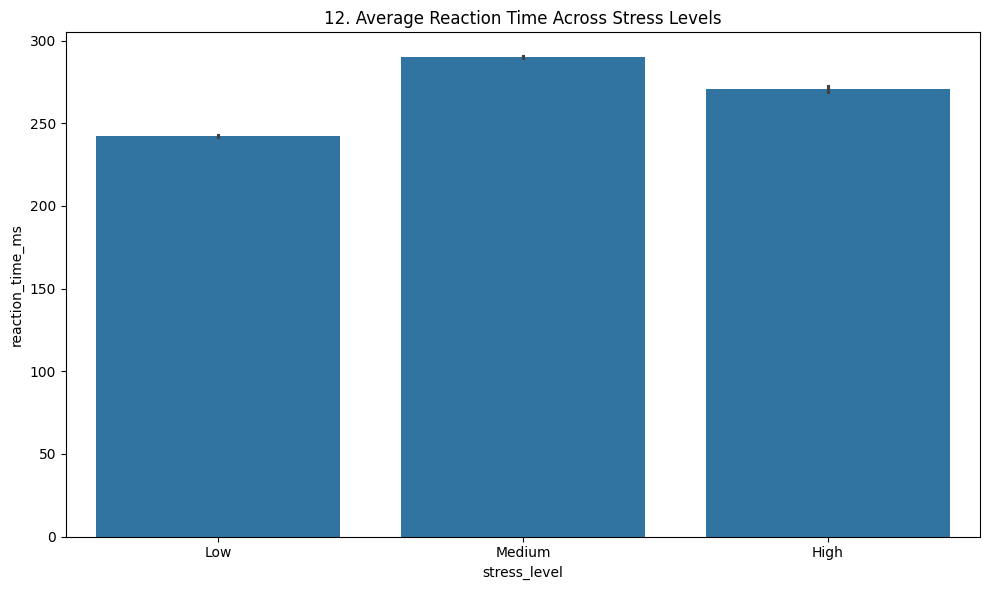

In [24]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='stress_level', y='reaction_time_ms', data=df, estimator='mean', order=['Low', 'Medium', 'High'])
plt.title(f'{plot_no}. Average Reaction Time Across Stress Levels')
show_fig()
plot_no += 1

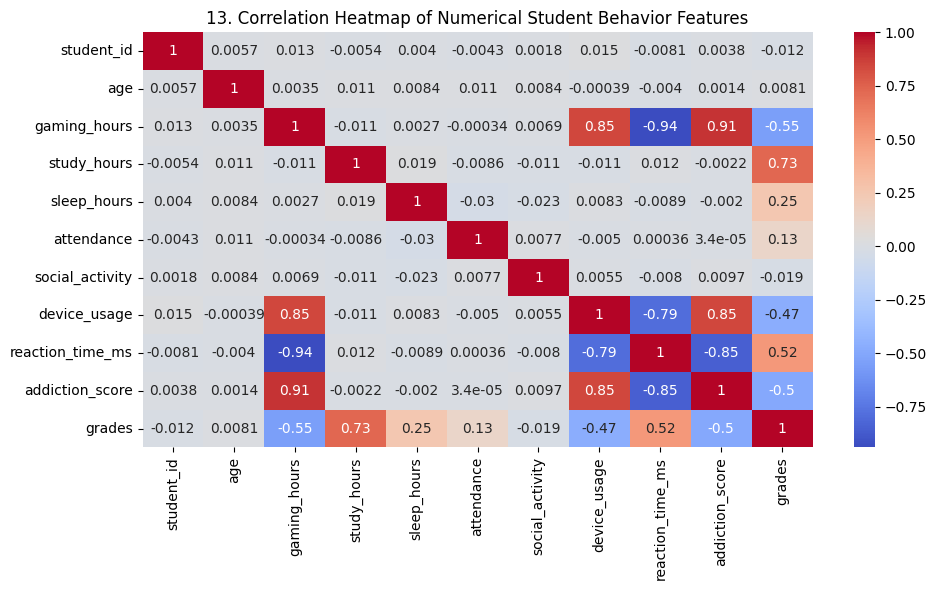

In [25]:
fig = plt.figure(figsize=(10,6))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Student Behavior Features')
show_fig()
plot_no += 1

In [26]:
corr

,student_id,age,gaming_hours,study_hours,sleep_hours,attendance,social_activity,device_usage,reaction_time_ms,addiction_score,grades
student_id,1.000000,0.005701,0.013262,-0.005397,0.003962,-0.004271,0.001827,0.015397,-0.008136,0.003835,-0.012087
age,0.005701,1.000000,0.003503,0.011244,0.008365,0.010693,0.008388,-0.000389,-0.004007,0.001377,0.008052
gaming_hours,0.013262,0.003503,1.000000,-0.010558,0.002699,-0.000337,0.006929,0.847920,-0.939266,0.909044,-0.551312
study_hours,-0.005397,0.011244,-0.010558,1.000000,0.018629,-0.008569,-0.010709,-0.011092,0.011824,-0.002204,0.733132
sleep_hours,0.003962,0.008365,0.002699,0.018629,1.000000,-0.030495,-0.022627,0.008339,-0.008932,-0.002034,0.250298
attendance,-0.004271,0.010693,-0.000337,-0.008569,-0.030495,1.000000,0.007738,-0.004957,0.000360,0.000034,0.130842
social_activity,0.001827,0.008388,0.006929,-0.010709,-0.022627,0.007738,1.000000,0.005501,-0.007969,0.009741,-0.018717
device_usage,0.015397,-0.000389,0.847920,-0.011092,0.008339,-0.004957,0.005501,1.000000,-0.791445,0.847297,-0.468472
reaction_time_ms,-0.008136,-0.004007,-0.939266,0.011824,-0.008932,0.000360,-0.007969,-0.791445,1.000000,-0.849808,0.517340
addiction_score,0.003835,0.001377,0.909044,-0.002204,-0.002034,0.000034,0.009741,0.847297,-0.849808,1.000000,-0.495055


# Model Training

## select features and target

In [27]:
X = df.drop(['student_id', 'grades'], axis=1)
y = df['grades']

## separate numeric and categorical columns

In [28]:
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

## create preprocessing with scaling and encoding

In [29]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

## create supervised regression model pipeline

In [30]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42))
])

## split dataset into training and testing data

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## train the model

In [32]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## predict test data

In [33]:
y_pred = model.predict(X_test)

## print model accuracy scores

In [34]:
print("R2 Accuracy Score:", r2_score(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Accuracy Score: 0.9266817976846915
Mean Absolute Error: 4.785480030262241
Root Mean Squared Error: 6.062243068270103


## plot actual vs predicted grades

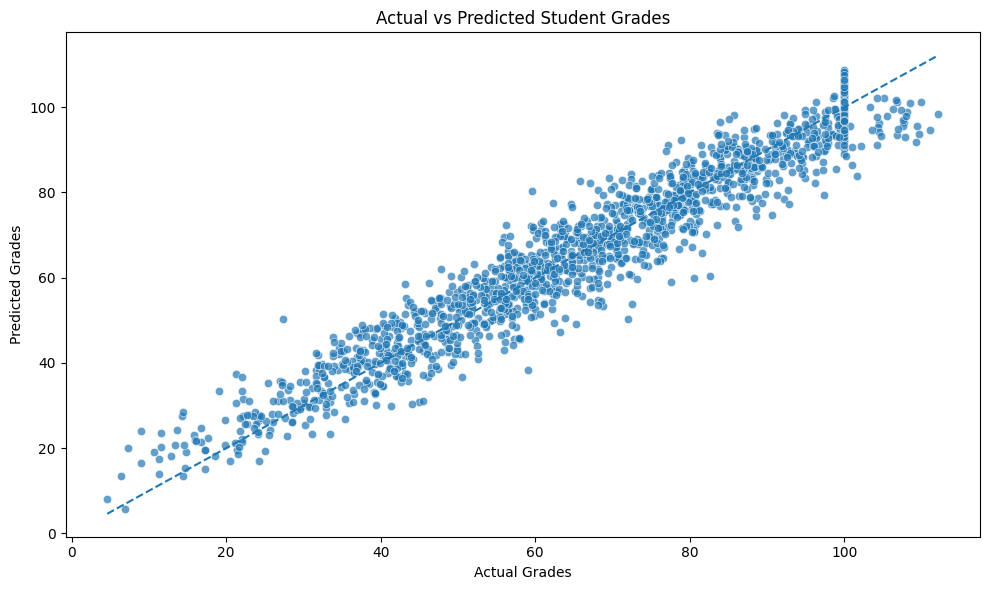

In [35]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--')
plt.xlabel("Actual Grades")
plt.ylabel("Predicted Grades")
plt.title("Actual vs Predicted Student Grades")
plt.tight_layout()
plt.show()